# Lab: Naive Bayes Classification with scikit-learn

In the [theory notes](./20_naive_bayes_theory.md), we learned that Naive Bayes is a **probabilistic classifier** based on **Bayes' Theorem**. Instead of finding a geometric boundary, it calculates $P(\text{class} | \text{features})$ — the probability of each class given the observed features — and picks the most likely one.

In the [implementation file](./21_naive_bayes_implementation.py), we built a `MultinomialNB` from scratch — computing priors, likelihoods with Laplace smoothing, and predictions in log space.

**Now it's time to use the real thing.** scikit-learn provides three Naive Bayes variants. In this lab, we'll focus on `GaussianNB` (for continuous features) and learn how to:

1. Load data and build a `GaussianNB` classifier.
2. Understand what **GaussianNB actually learns** (the per-class mean and variance for each feature).
3. **Visualize the learned Gaussian distributions** overlaid on the data.
4. **Visualize decision boundaries** and understand why they look different from KNN or SVM.
5. Explore the **key parameters** (`var_smoothing`, `priors`).
6. Understand **why scaling is NOT required** for Naive Bayes.
7. See **when the Naive (independence) assumption helps and when it hurts**.

---

## 1. The Dataset

We'll use the **Iris dataset** — the same classic multi-class classification benchmark from earlier labs. The goal is to classify iris flowers into three species (*setosa*, *versicolor*, *virginica*) based on four petal/sepal measurements.

Gaussian Naive Bayes assumes each feature follows a **normal distribution** within each class. The Iris features are continuous measurements that roughly satisfy this assumption, making it a natural fit.

Let's start by importing our libraries and loading the data.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 150

In [2]:
# Load the Iris dataset
iris = load_iris()

feature_names = list(iris.feature_names)
target_names = list(iris.target_names)

df = pd.DataFrame(iris.data, columns=feature_names)
df["species"] = [target_names[t] for t in iris.target]
df["target"] = iris.target

X = df[feature_names].values
y = df["target"].values

print(f"Dataset: {df.shape[0]} samples, {len(feature_names)} features")
print(f"Classes: {target_names}")
print(f"Class distribution:\n{df['species'].value_counts().to_string()}")
print()
df.sample(5, random_state=42)

Dataset: 150 samples, 4 features
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class distribution:
species
setosa        50
versicolor    50
virginica     50



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,target
73,6.1,2.8,4.7,1.2,versicolor,1
18,5.7,3.8,1.7,0.3,setosa,0
118,7.7,2.6,6.9,2.3,virginica,2
78,6.0,2.9,4.5,1.5,versicolor,1
76,6.8,2.8,4.8,1.4,versicolor,1


---

## 2. No Scaling Required!

Unlike KNN and SVM (which compute distances or margins), Naive Bayes **does not need feature scaling**.

Why? Because GaussianNB models each feature **independently** within each class using:

$$P(x_i | y=c) = \frac{1}{\sqrt{2\pi\sigma_{c,i}^2}} \exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2}\right)$$

Each feature gets its **own** mean ($\mu$) and variance ($\sigma^2$), so features on different scales don't interfere with each other. A feature ranging 0–7 and one ranging 0–0.5 are handled perfectly well — each gets its own Gaussian distribution.

This is a key advantage of Naive Bayes: **no preprocessing beyond basic cleaning is needed.**

---

## 3. Building a GaussianNB Classifier

scikit-learn's `GaussianNB` is very lightweight. Key parameters:

| Parameter | What It Does | Default |
|---|---|---|
| `priors` | Prior probabilities for each class. If `None`, learned from data as class frequencies. | `None` |
| `var_smoothing` | A tiny amount added to all variances to prevent division by zero (similar in spirit to Laplace smoothing). | `1e-9` |

That's it — **GaussianNB has essentially no hyperparameters to tune**. Training is just "counting" — computing the mean and variance of each feature for each class.

From the theory:
> *"Unlike SVM or Logistic Regression, Naive Bayes does not use optimization algorithms like Gradient Descent. There is no iterative 'learning.' Training is simply counting."*

In [3]:
# Build and train a GaussianNB classifier
gnb = GaussianNB()
gnb.fit(X, y)

print("GaussianNB model ready!")
print(f"  Classes: {gnb.classes_}")
print(f"  var_smoothing: {gnb.var_smoothing}")
print(f"\n📌 What did .fit() actually compute? Just means and variances:")
print(f"  theta_ (class means) shape: {gnb.theta_.shape}  → {len(gnb.classes_)} classes × {len(feature_names)} features")
print(f"  var_ (class variances) shape: {gnb.var_.shape}  → same shape")

GaussianNB model ready!
  Classes: [0 1 2]
  var_smoothing: 1e-09

📌 What did .fit() actually compute? Just means and variances:
  theta_ (class means) shape: (3, 4)  → 3 classes × 4 features
  var_ (class variances) shape: (3, 4)  → same shape


---

## 4. What GaussianNB Learned: Per-Class Means and Variances

The entire "model" is captured by two arrays:
- **`theta_`**: The mean of each feature for each class ($\mu_{c,i}$)
- **`var_`**: The variance of each feature for each class ($\sigma^2_{c,i}$)

Plus the class priors:
- **`class_prior_`**: $P(y=c)$ — the fraction of training samples in each class

Let's inspect these:

In [4]:
# Display the learned parameters in a readable format
print("Class Priors P(y=c):")
for name, prior in zip(target_names, gnb.class_prior_):
    print(f"  P({name}) = {prior:.4f}")

print(f"\nPer-Class Means (theta_):")
means_df = pd.DataFrame(gnb.theta_, index=target_names, columns=feature_names)
print(means_df.round(3).to_string())

print(f"\nPer-Class Variances (var_):")
var_df = pd.DataFrame(gnb.var_, index=target_names, columns=feature_names)
print(var_df.round(4).to_string())

print(f"\n📌 This is the ENTIRE model. GaussianNB stores just {gnb.theta_.size + gnb.var_.size + len(gnb.class_prior_)} numbers.")
print(f"   Compare this to KNN, which stores all {X.shape[0]} × {X.shape[1]} = {X.size} training values.")

Class Priors P(y=c):
  P(setosa) = 0.3333
  P(versicolor) = 0.3333
  P(virginica) = 0.3333

Per-Class Means (theta_):
            sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
setosa                  5.006             3.428              1.462             0.246
versicolor              5.936             2.770              4.260             1.326
virginica               6.588             2.974              5.552             2.026

Per-Class Variances (var_):
            sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
setosa                 0.1218            0.1408             0.0296            0.0109
versicolor             0.2611            0.0965             0.2164            0.0383
virginica              0.3963            0.1019             0.2985            0.0739

📌 This is the ENTIRE model. GaussianNB stores just 27 numbers.
   Compare this to KNN, which stores all 150 × 4 = 600 training values.


---

## 5. Visualizing the Learned Gaussian Distributions

For each feature, GaussianNB fits a **separate Gaussian (bell curve)** per class. At prediction time, it evaluates where the new data point falls on each of these curves.

Let's plot the actual data distributions alongside the Gaussians that GaussianNB learned:

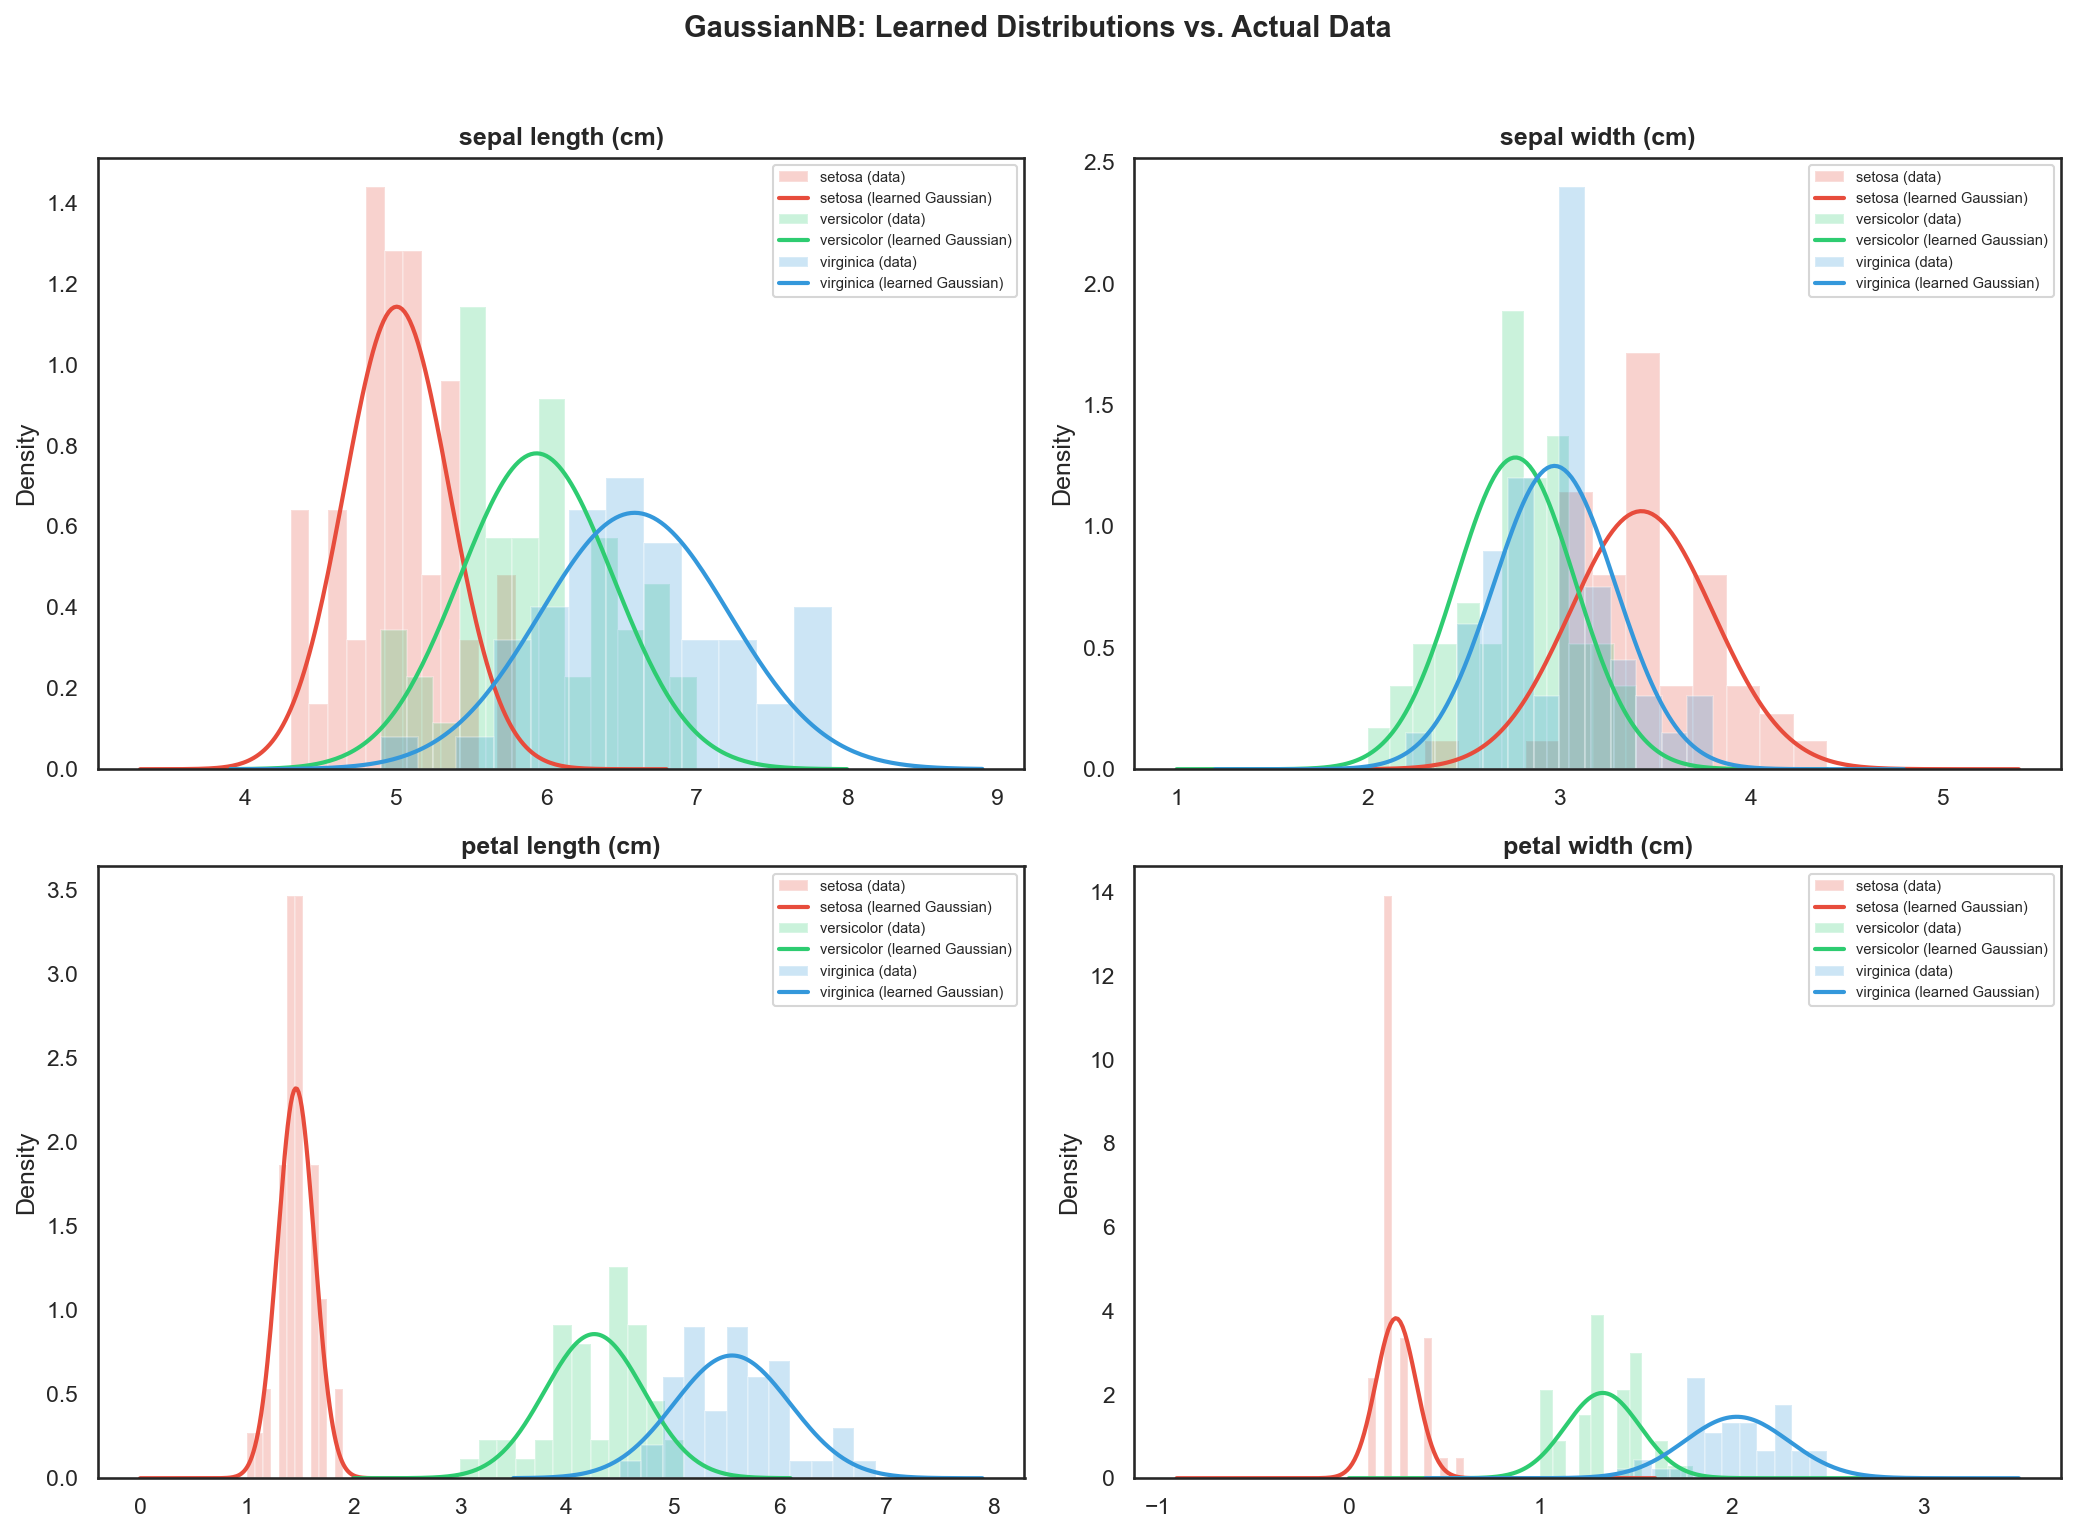

📌 Each bell curve is a Gaussian N(μ, σ²) that GaussianNB learned for one (feature, class) pair.
   To classify a new flower, it evaluates the new point's position on ALL of these curves,
   multiplies the results together (the 'Naive' independence assumption), and picks the
   class with the highest combined probability.


In [5]:
colors = ["#e74c3c", "#2ecc71", "#3498db"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (ax, fname) in enumerate(zip(axes.ravel(), feature_names)):
    for c, (name, color) in enumerate(zip(target_names, colors)):
        # Get the data for this class
        class_data = X[y == c, idx]

        # Plot histogram of actual data
        ax.hist(class_data, bins=12, alpha=0.25, color=color, density=True, label=f"{name} (data)")

        # Plot the Gaussian PDF that GaussianNB learned
        mu = gnb.theta_[c, idx]
        sigma = np.sqrt(gnb.var_[c, idx])
        x_range = np.linspace(class_data.min() - 1, class_data.max() + 1, 200)
        pdf = stats.norm.pdf(x_range, mu, sigma)
        ax.plot(x_range, pdf, color=color, linewidth=2, label=f"{name} (learned Gaussian)")

    ax.set_title(fname, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("GaussianNB: Learned Distributions vs. Actual Data", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Each bell curve is a Gaussian N(μ, σ²) that GaussianNB learned for one (feature, class) pair.")
print("   To classify a new flower, it evaluates the new point's position on ALL of these curves,")
print("   multiplies the results together (the 'Naive' independence assumption), and picks the")
print("   class with the highest combined probability.")

---

## 6. How a Prediction Works: Step by Step

Let's trace through exactly how GaussianNB classifies a single flower. This connects directly to the Bayes' Theorem formula from the theory:

$$\hat{y} = \underset{c}{\arg\max} \left( P(y=c) \cdot \prod_{i=1}^{n} P(x_i | y=c) \right)$$

In practice, we work in **log space** to avoid numerical underflow (as the theory warns).

In [6]:
# Pick a sample to trace through
sample_idx = 75
sample = X[sample_idx:sample_idx+1]

print(f"Query point (index {sample_idx}): {target_names[y[sample_idx]]}")
print(f"Feature values: {dict(zip(feature_names, sample[0].round(2)))}")
print()

# Manually compute log-likelihoods step by step
print("Step-by-step Bayesian computation (in log space):")
print("=" * 70)

for c, name in enumerate(target_names):
    log_prior = np.log(gnb.class_prior_[c])
    print(f"\nClass: {name}")
    print(f"  log P({name}) = {log_prior:.4f}")

    total_log_likelihood = log_prior
    for i, fname in enumerate(feature_names):
        mu = gnb.theta_[c, i]
        var = gnb.var_[c, i]
        x_val = sample[0, i]
        log_prob = stats.norm.logpdf(x_val, mu, np.sqrt(var))
        total_log_likelihood += log_prob
        print(f"  + log P({fname}={x_val:.1f} | {name}) = {log_prob:.4f}")

    print(f"  → Total log-posterior: {total_log_likelihood:.4f}")

# Compare with scikit-learn's output
print(f"\n{'=' * 70}")
print(f"scikit-learn prediction: {target_names[gnb.predict(sample)[0]]}")
print(f"scikit-learn predict_proba: {dict(zip(target_names, gnb.predict_proba(sample)[0].round(6)))}")
print(f"\n📌 The class with the highest total log-posterior wins. That's all Naive Bayes does.")

Query point (index 75): versicolor
Feature values: {'sepal length (cm)': np.float64(6.6), 'sepal width (cm)': np.float64(3.0), 'petal length (cm)': np.float64(4.4), 'petal width (cm)': np.float64(1.4)}

Step-by-step Bayesian computation (in log space):

Class: setosa
  log P(setosa) = -1.0986
  + log P(sepal length (cm)=6.6 | setosa) = -10.2995
  + log P(sepal width (cm)=3.0 | setosa) = -0.5892
  + log P(petal length (cm)=4.4 | setosa) = -145.1834
  + log P(petal width (cm)=1.4 | setosa) = -59.8364
  → Total log-posterior: -217.0072

Class: versicolor
  log P(versicolor) = -1.0986
  + log P(sepal length (cm)=6.6 | versicolor) = -1.0918
  + log P(sepal width (cm)=3.0 | versicolor) = -0.0239
  + log P(petal length (cm)=4.4 | versicolor) = -0.1989
  + log P(petal width (cm)=1.4 | versicolor) = 0.6405
  → Total log-posterior: -1.7728

Class: virginica
  log P(virginica) = -1.0986
  + log P(sepal length (cm)=6.6 | virginica) = -0.4563
  + log P(sepal width (cm)=3.0 | virginica) = 0.2195
  +

---

## 7. Visualizing Decision Boundaries

Let's see how GaussianNB partitions the feature space. We'll use two features (petal length and petal width) for 2D visualization, and compare it with what you've seen from KNN:

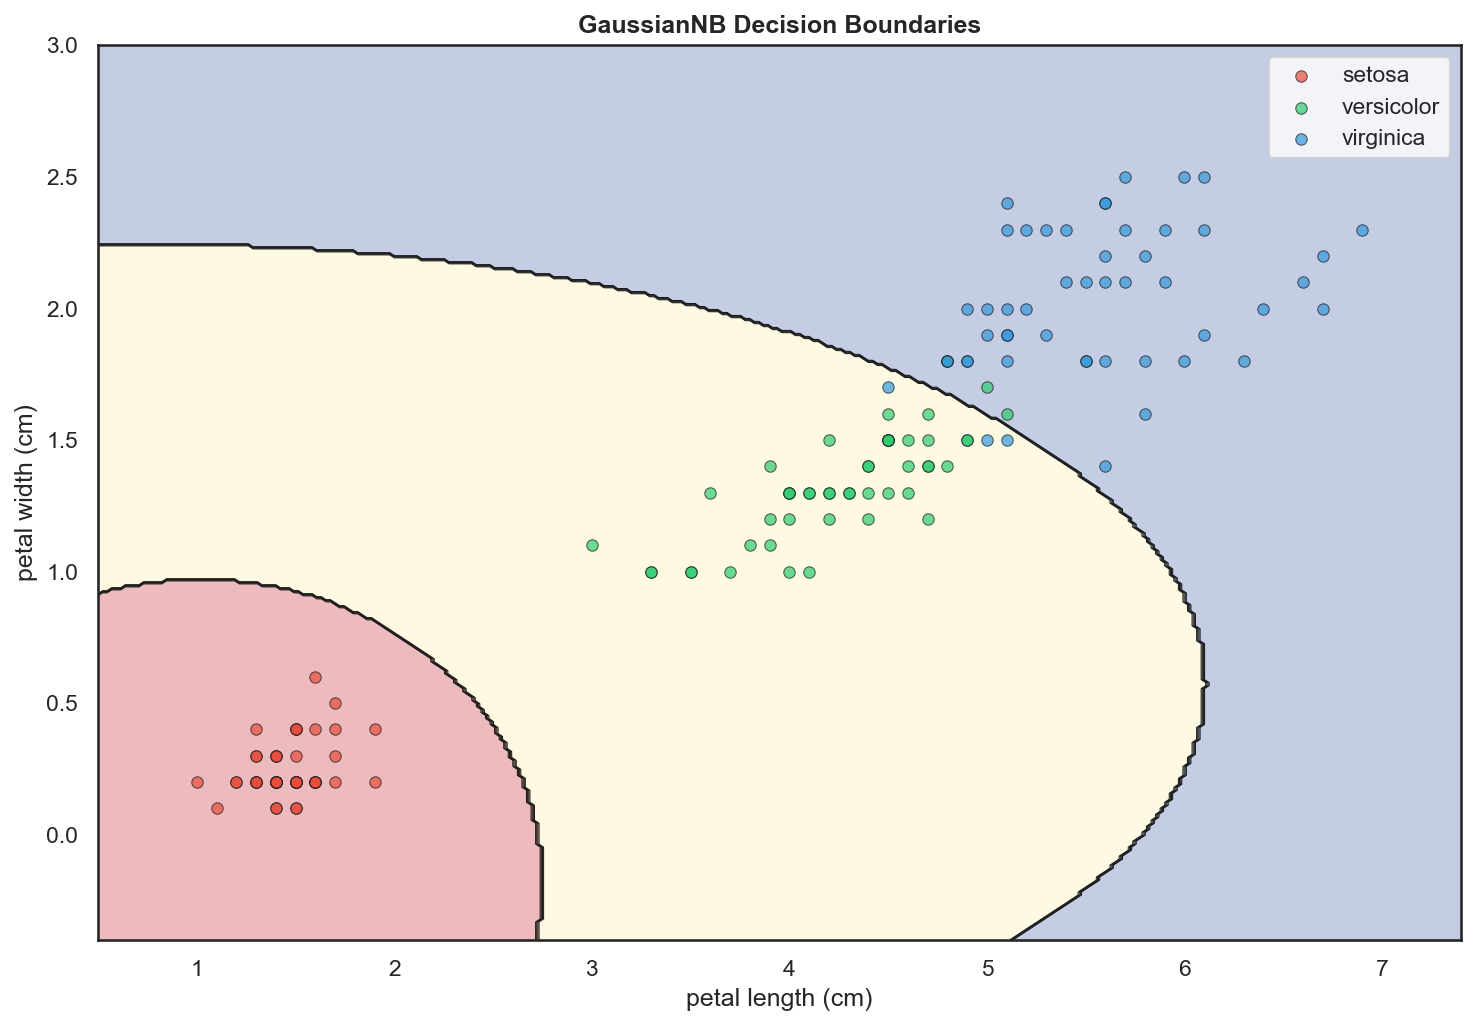

📌 Notice: The decision boundaries are smooth CURVES (quadratic), not straight lines.
   This is because each class has its own variance, so the Gaussian 'bells' have
   different widths — the boundary is where two Gaussians cross.
   Compare this to KNN's jagged boundaries or SVM's straight margins.


In [7]:
# Use only petal features for 2D visualization
X_2d = X[:, 2:4]  # petal_length (idx 2), petal_width (idx 3)
feature_pair = ["petal length (cm)", "petal width (cm)"]

model_2d = GaussianNB()
model_2d.fit(X_2d, y)

# Create mesh grid
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
ax.contour(xx, yy, Z, colors="k", linewidths=0.5)

for i, (name, color) in enumerate(zip(target_names, colors)):
    mask = y == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=30,
               edgecolors="k", linewidths=0.5, alpha=0.7)

ax.set_xlabel(feature_pair[0])
ax.set_ylabel(feature_pair[1])
ax.set_title("GaussianNB Decision Boundaries", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("📌 Notice: The decision boundaries are smooth CURVES (quadratic), not straight lines.")
print("   This is because each class has its own variance, so the Gaussian 'bells' have")
print("   different widths — the boundary is where two Gaussians cross.")
print("   Compare this to KNN's jagged boundaries or SVM's straight margins.")

---

## 8. Prediction Confidence: `predict_proba()`

Unlike many classifiers, Naive Bayes produces **genuine probability estimates** (based on Bayes' Theorem). These probabilities have a meaningful interpretation — they represent the model's confidence based on the Gaussian assumptions.

Let's visualize how confident the model is across the feature space:

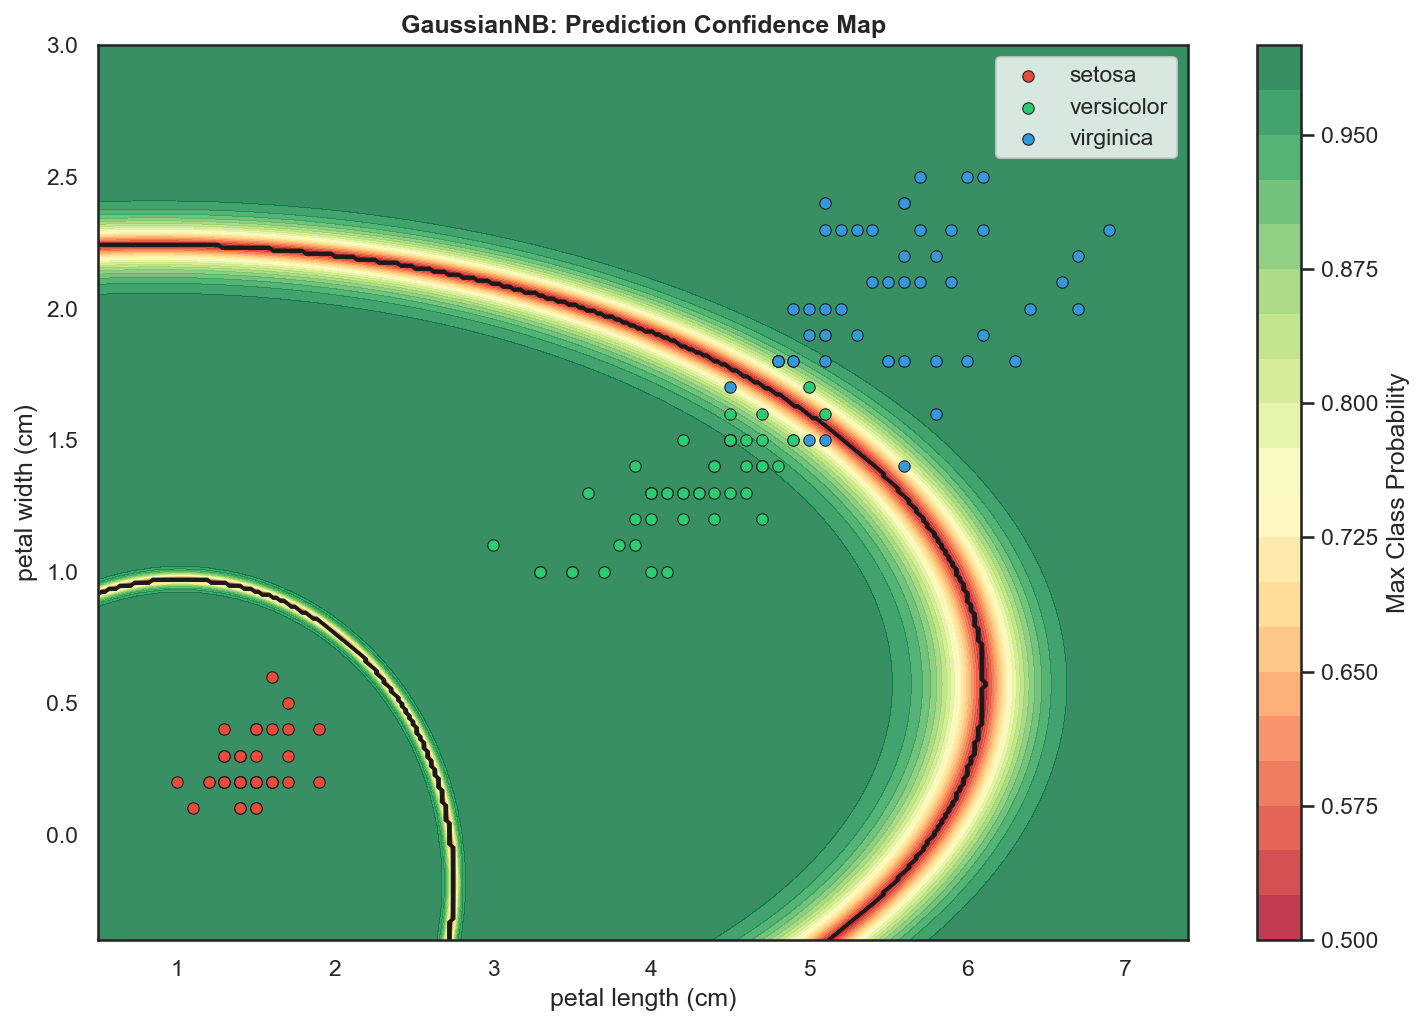

📌 Green = high confidence (close to 1.0), Red/Yellow = low confidence (near boundary).
   The model is least confident near the decision boundaries, which is exactly where
   the Gaussian distributions of two classes overlap.


In [8]:
# Compute max prediction probability at each point in the grid
Z_proba = model_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z_confidence = Z_proba.max(axis=1).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.contourf(xx, yy, Z_confidence, levels=20, cmap="RdYlGn", alpha=0.8)
ax.contour(xx, yy, Z, colors="k", linewidths=1)

for i, (name, color) in enumerate(zip(target_names, colors)):
    mask = y == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=30,
               edgecolors="k", linewidths=0.5)

plt.colorbar(im, ax=ax, label="Max Class Probability")
ax.set_xlabel(feature_pair[0])
ax.set_ylabel(feature_pair[1])
ax.set_title("GaussianNB: Prediction Confidence Map", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print("📌 Green = high confidence (close to 1.0), Red/Yellow = low confidence (near boundary).")
print("   The model is least confident near the decision boundaries, which is exactly where")
print("   the Gaussian distributions of two classes overlap.")

---

## 9. The "Naive" Assumption: When It Helps and When It Hurts

The theory emphasizes:
> *"It assumes that all features are independent of each other given the class."*

And under common pitfalls:
> *"If you have two features that are identical (e.g., 'price_in_dollars' and 'price_in_euros'), Naive Bayes will 'double count' their importance."*

Let's demonstrate this. We'll compare GaussianNB on the original features versus a version where we add a **redundant (correlated) feature**:

In [9]:
# Original: fit on petal_length and petal_width
gnb_original = GaussianNB().fit(X_2d, y)
proba_original = gnb_original.predict_proba(X_2d)

# Add a redundant feature: petal_width * 2.54 (same info, different units)
X_redundant = np.c_[X_2d, X_2d[:, 1] * 2.54]  # petal_width in "inches" (correlated)
gnb_redundant = GaussianNB().fit(X_redundant, y)
proba_redundant = gnb_redundant.predict_proba(X_redundant)

# Compare confidence on borderline samples (versicolor/virginica boundary)
borderline_indices = [70, 77, 83, 106, 119, 133]

print(f"{'Index':<8} {'True Class':<14} {'Original Conf.':<18} {'Redundant Conf.':<18} {'Diff':>8}")
print("-" * 66)
for idx in borderline_indices:
    true_class = target_names[y[idx]]
    conf_orig = proba_original[idx].max()
    conf_redund = proba_redundant[idx].max()
    diff = conf_redund - conf_orig
    print(f"{idx:<8} {true_class:<14} {conf_orig:<18.4f} {conf_redund:<18.4f} {diff:>+8.4f}")

print(f"\n📌 Adding a redundant feature (petal_width in different units) changes the probabilities.")
print(f"   NB 'double counts' correlated information, making the model overconfident in")
print(f"   whichever direction the repeated feature points.")
print(f"   This is the main downside of the Naive independence assumption.")

Index    True Class     Original Conf.     Redundant Conf.        Diff
------------------------------------------------------------------
70       versicolor     0.8609             0.9834              +0.1225
77       versicolor     0.7976             0.8956              +0.0980
83       versicolor     0.6343             0.5064              -0.1279
106      virginica      0.7510             0.5809              -0.1701
119      virginica      0.7704             0.9533              +0.1828
133      virginica      0.6632             0.9229              +0.2597

📌 Adding a redundant feature (petal_width in different units) changes the probabilities.
   NB 'double counts' correlated information, making the model overconfident in
   whichever direction the repeated feature points.
   This is the main downside of the Naive independence assumption.


---

## 10. The `var_smoothing` Parameter

The theory discusses **Laplace smoothing** for Multinomial NB. For GaussianNB, the equivalent is `var_smoothing` — a tiny fraction of the largest variance that gets added to all feature variances.

Why? If a feature has **zero variance** in some class (all values are identical), the Gaussian PDF would produce infinity. `var_smoothing` prevents this.

Let's see how different `var_smoothing` values affect the decision boundaries:

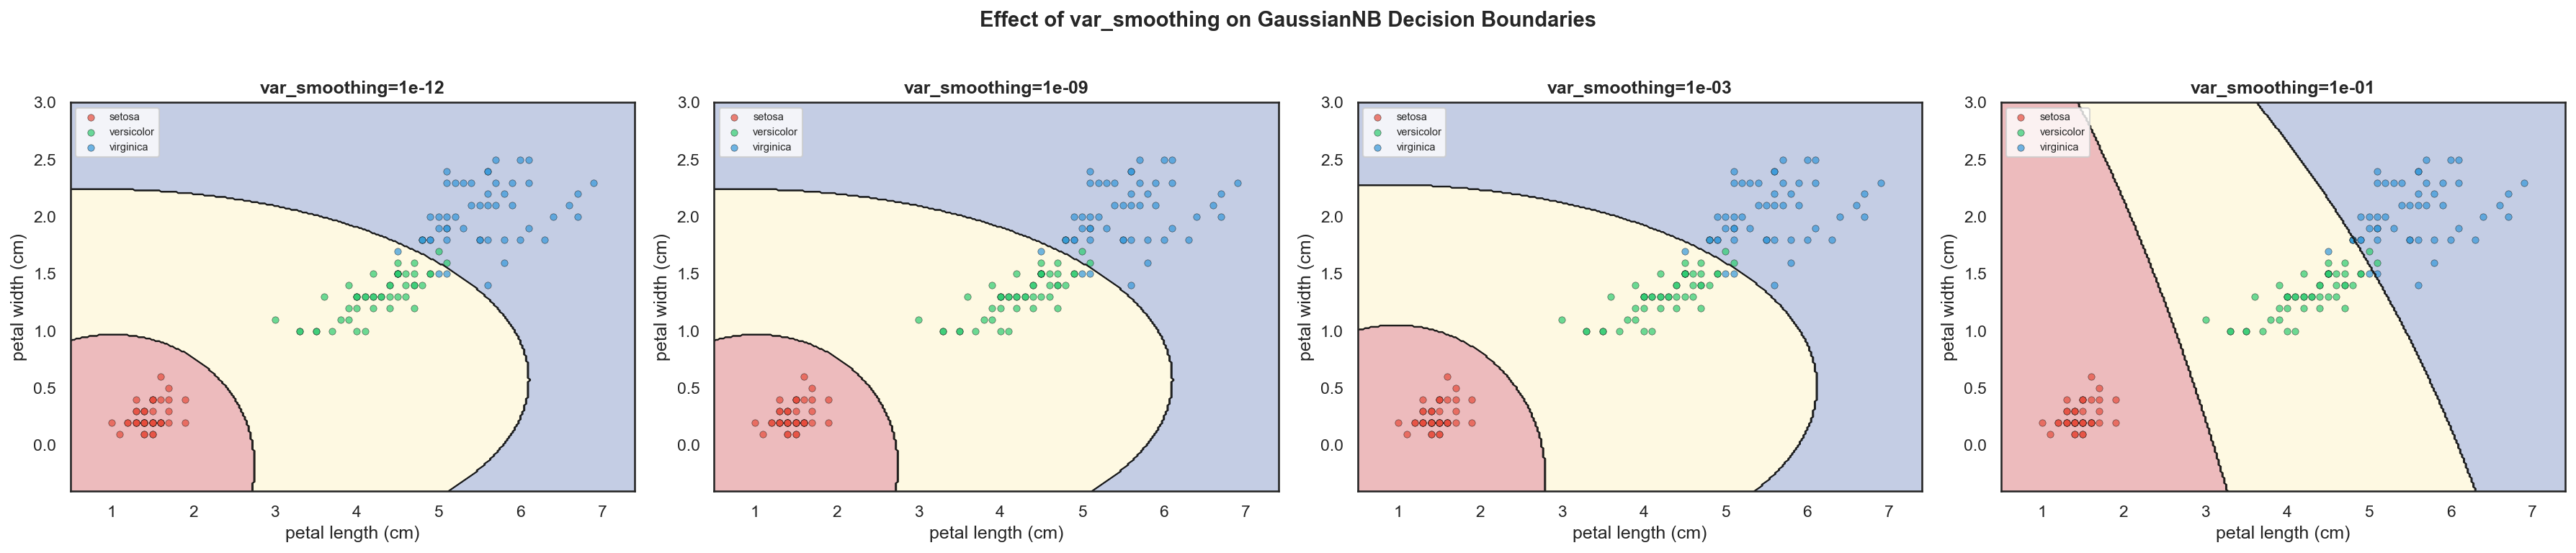

📌 Very small var_smoothing (left): Sharp boundaries — the Gaussians are 'narrow',
   so the model is very sensitive to exact feature values.
   Large var_smoothing (right): 'Wider' Gaussians — boundaries become more linear
   and the model becomes less sensitive. This is like a regularization effect.


In [10]:
var_smoothing_values = [1e-12, 1e-9, 1e-3, 1e-1]

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, vs in zip(axes, var_smoothing_values):
    model = GaussianNB(var_smoothing=vs)
    model.fit(X_2d, y)

    Z_vs = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z_vs, alpha=0.3, cmap="RdYlBu")
    ax.contour(xx, yy, Z_vs, colors="k", linewidths=0.5)

    for i, (name, color) in enumerate(zip(target_names, colors)):
        mask = y == i
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, s=20,
                   edgecolors="k", linewidths=0.3, alpha=0.7)

    ax.set_xlabel(feature_pair[0])
    ax.set_ylabel(feature_pair[1])
    ax.set_title(f"var_smoothing={vs:.0e}", fontweight="bold")
    ax.legend(loc="upper left", fontsize=7)

fig.suptitle("Effect of var_smoothing on GaussianNB Decision Boundaries", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("📌 Very small var_smoothing (left): Sharp boundaries — the Gaussians are 'narrow',")
print("   so the model is very sensitive to exact feature values.")
print("   Large var_smoothing (right): 'Wider' Gaussians — boundaries become more linear")
print("   and the model becomes less sensitive. This is like a regularization effect.")

---

## 11. Speed: Naive Bayes is Extremely Fast

The theory states Naive Bayes is "extremely fast." Let's verify:

In [11]:
import time

model = GaussianNB()

# Time training
start = time.perf_counter()
for _ in range(1000):
    model.fit(X, y)
fit_time = (time.perf_counter() - start) / 1000

# Time prediction
start = time.perf_counter()
for _ in range(1000):
    model.predict(X)
predict_time = (time.perf_counter() - start) / 1000

print(f"Average .fit() time:     {fit_time*1000:.4f} ms  (compute 3 × 4 = 12 means and 12 variances)")
print(f"Average .predict() time: {predict_time*1000:.4f} ms  (evaluate Gaussians for 150 samples)")
print(f"\n📌 Both training AND prediction are extremely fast.")
print(f"   Training: O(n × d) — one pass through the data to compute means/variances.")
print(f"   Prediction: O(k × d) per sample — evaluate d Gaussian PDFs for k classes.")
print(f"   Compare to KNN which is O(n) per prediction (must compute distance to ALL training points).")

Average .fit() time:     0.2151 ms  (compute 3 × 4 = 12 means and 12 variances)
Average .predict() time: 0.0572 ms  (evaluate Gaussians for 150 samples)

📌 Both training AND prediction are extremely fast.
   Training: O(n × d) — one pass through the data to compute means/variances.
   Prediction: O(k × d) per sample — evaluate d Gaussian PDFs for k classes.
   Compare to KNN which is O(n) per prediction (must compute distance to ALL training points).


---

## 12. Naive Bayes Variants in scikit-learn

The theory describes three Naive Bayes variants:

| Variant | When to Use | scikit-learn Class | Likelihood Model |
|---|---|---|---|
| **Gaussian NB** | Continuous features (measurements, readings) | `GaussianNB` | Normal distribution per feature per class |
| **Multinomial NB** | Discrete counts (word frequencies, event counts) | `MultinomialNB` | Multinomial distribution (counting) |
| **Bernoulli NB** | Binary features (word present/absent) | `BernoulliNB` | Bernoulli distribution (yes/no) |

We used **GaussianNB** because our Iris features are continuous measurements. If you move on to text classification (the classic NB use case), you'd use `MultinomialNB` — which is what we built from scratch in the implementation file.

---

## Summary

In this lab, we learned how to use scikit-learn's `GaussianNB` for classification. Here's what we covered:

| Step | What We Did | Key scikit-learn API |
|------|-------------|---------------------|
| Load data | Iris dataset (150 flowers, 3 species) | `load_iris()` |
| No scaling needed | Explained why NB doesn't need feature scaling | — |
| Build GaussianNB | Trained the classifier | `GaussianNB().fit(X, y)` |
| Inspect learned params | Viewed per-class means, variances, and priors | `.theta_`, `.var_`, `.class_prior_` |
| Visualize Gaussians | Plotted the learned distributions vs. actual data | `scipy.stats.norm.pdf()` |
| Trace a prediction | Walked through Bayes' Theorem step by step | `.predict_proba()`, log-likelihood computation |
| Decision boundaries | Visualized the smooth, curved class regions | `.predict()` on a mesh grid |
| Confidence map | Showed where the model is certain vs. uncertain | `.predict_proba()` |
| Independence assumption | Demonstrated the "double counting" pitfall with correlated features | Compared original vs. redundant features |
| var_smoothing | Showed how it acts as a regularizer | `var_smoothing` parameter |
| Speed | Timed training and prediction | `time.perf_counter()` |
| NB variants | Summarized Gaussian, Multinomial, and Bernoulli NB | `GaussianNB`, `MultinomialNB`, `BernoulliNB` |

The key takeaways are:

1. **Naive Bayes is probabilistic** — it classifies by computing $P(\text{class} | \text{features})$ using Bayes' Theorem, not by finding geometric boundaries.
2. **GaussianNB fits a Gaussian per (feature, class) pair** — the entire model is just a table of means and variances.
3. **No scaling is needed** — each feature is modeled independently with its own distribution.
4. **No hyperparameters to tune** — `var_smoothing` rarely needs adjustment.
5. **It's extremely fast** — training is O(n × d), prediction is O(k × d).
6. **The "Naive" assumption** — feature independence is almost always violated, yet the model performs surprisingly well. But watch out for **redundant (correlated) features** which get double-counted.
7. **Choose the right variant**: `GaussianNB` for continuous features, `MultinomialNB` for discrete counts, `BernoulliNB` for binary features.

---

**Next:** [Bias, Variance, and Ensemble Models Theory](./23_bias_variance_and_ensemble_models_theory.md)